In [1]:
import os

import math

import numpy as np

import pandas as pd

import scipy.stats

import altair as alt

import dms_variants.codonvarianttable

import plotnine as pn

import scipy.stats

import  yaml 

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

In [2]:
# allow more rows for Altair
_ = alt.data_transformers.disable_max_rows()

In [3]:
# If you are running notebook interactively rather than in pipeline that handles
# working directories, you may have to first `os.chdir` to appropriate directory.

with open("config.yaml") as f:
    config = yaml.safe_load(f)

In [4]:
functional_selections = pd.read_csv(config["functional_selections"])

In [5]:
func_scores = pd.concat(
    [
        pd.read_csv(
            os.path.join(config["func_score_dir"], f"{selection_name}_merged_mapped_pipeline.csv"),
            na_filter=False,
        )
        for selection_name in functional_selections["selection_name"]
    ],
    ignore_index=True,
)

assert len(func_scores) == len(func_scores.drop_duplicates())

In [44]:
# get data to plot

preselection_count_boxplot_df = (
    func_scores[
        [
            "library",
            "pre_sample",
            "pre_count",
            "barcode",
            "pre_count_threshold",
        ]
    ]
    .drop_duplicates()
    .assign(
        variant_above_threshold=lambda x: (
            x["pre_count"] >= x["pre_count_threshold"]
        ).astype(int),

        count_above_threshold=lambda x: (
            x["pre_count"] * x["variant_above_threshold"]
        ),
    )
    .groupby(
        ["library", "pre_sample", "pre_count_threshold"],
        as_index=False,
    )
    .aggregate(
        median=pd.NamedAgg(
            column="pre_count",
            aggfunc="median",
        ),

        percentile_25=pd.NamedAgg(
            column="pre_count",
            aggfunc=lambda s: s.quantile(0.25),
        ),

        percentile_75=pd.NamedAgg(
            column="pre_count",
            aggfunc=lambda s: s.quantile(0.75),
        ),

        min=pd.NamedAgg(
            column="pre_count",
            aggfunc="min",
        ),

        max=pd.NamedAgg(
            column="pre_count",
            aggfunc="max",
        ),

        nvariants=pd.NamedAgg(
            column="barcode",
            aggfunc="count",
        ),

        total_counts=pd.NamedAgg(
            column="pre_count",
            aggfunc="sum",
        ),

        variants_above_threshold=pd.NamedAgg(
            column="variant_above_threshold",
            aggfunc="sum",
        ),

        counts_above_threshold=pd.NamedAgg(
            column="count_above_threshold",
            aggfunc="sum",
        ),
    )
    .assign(
        library_sample=lambda x: (
            x["library"] + " " + x["pre_sample"]
        ),

        frac_counts_above_threshold=lambda x: (
            x["counts_above_threshold"]
            / x["total_counts"]
        ),

        frac_variants_above_threshold=lambda x: (
            x["variants_above_threshold"]
            / x["nvariants"]
        ),
    )
    .drop(
        columns=[
            "counts_above_threshold",
            "variants_above_threshold",
            "total_counts",
            "nvariants",
        ]
    )
    .merge(
        functional_selections.rename(
            columns={
                "preselection_sample": "pre_sample"
            }
        )[
            [
                "pre_sample",
                "virus_batch",
                "library",
            ]
        ].drop_duplicates(),

        how="left",

        validate="one_to_one",
    )
)

assert (
    len(preselection_count_boxplot_df)
    == preselection_count_boxplot_df["library_sample"].nunique()
)


# preserve pipeline ordering:
# all A first, then all B,


selection_order = (
    functional_selections[
        ["library", "preselection_sample"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

selection_order["within_library_order"] = (
    selection_order
    .groupby("library")
    .cumcount()
)

preselection_count_boxplot_df = (
    preselection_count_boxplot_df
    .merge(
        selection_order.rename(
            columns={
                "preselection_sample": "pre_sample"
            }
        ),
        on=["library", "pre_sample"],
        how="left",
    )
)

preselection_count_boxplot_df = (
    preselection_count_boxplot_df
    .sort_values(
        by=[
            "library",
            "within_library_order",
        ]
    )
    .reset_index(drop=True)
)

# preserve plotting order

ordered_library_samples = (
    preselection_count_boxplot_df["library_sample"]
    .tolist()
)

preselection_count_boxplot_df["library_sample"] = pd.Categorical(
    preselection_count_boxplot_df["library_sample"],
    categories=ordered_library_samples,
    ordered=True,
)


# convert dtypes to standard numpy/python types

for col in preselection_count_boxplot_df.columns:

    if str(preselection_count_boxplot_df[col].dtype) == "Int64":

        preselection_count_boxplot_df[col] = (
            preselection_count_boxplot_df[col]
            .astype("int64")
        )

    elif str(preselection_count_boxplot_df[col].dtype) == "Float64":

        preselection_count_boxplot_df[col] = (
            preselection_count_boxplot_df[col]
            .astype("float64")
        )

    elif "string" in str(preselection_count_boxplot_df[col].dtype):

        preselection_count_boxplot_df[col] = (
            preselection_count_boxplot_df[col]
            .astype("object")
        )

print(
    preselection_count_boxplot_df[
        ["library_sample"]
    ]
)

print(
    preselection_count_boxplot_df.dtypes
)

                         library_sample
0  A 2022-07-20_rescue-2_VSVG_control_1
1  A 2022-07-20_rescue-2_VSVG_control_2
2  A 2022-08-04_rescue-1_VSVG_control_1
3  A 2022-08-04_rescue-1_VSVG_control_2
4  A 2022-09-01_rescue-3_VSVG_control_1
5  A 2022-09-27_rescue-3_VSVG_control_1
6  A 2022-10-17_rescue-4_VSVG_control_1
7  B 2022-08-04_rescue-2_VSVG_control_1
8  B 2022-08-04_rescue-2_VSVG_control_2
9  B 2022-09-12_rescue-1_VSVG_control_1
library                               str
pre_sample                            str
pre_count_threshold                 int64
median                            float64
percentile_25                     float64
percentile_75                     float64
min                                 int64
max                                 int64
library_sample                   category
frac_counts_above_threshold       float64
frac_variants_above_threshold     float64
virus_batch                           str
within_library_order                int64
dtype: object


#### This plot answers the question: "What is the distribution of variant counts across all samples before selection, and do they meet the minimum count threshold for functional score analysis?"
Pre-selection count distributions were examined across all samples. Median variant counts exceeded the minimum count threshold in every sample, indicating adequate sequencing depth and representation of variants prior to selection. The majority of variants were therefore expected to meet the minimum count requirements for downstream functional score analysis

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


def plot_filtered(library, virus_batch):

    filtered = preselection_count_boxplot_df.copy()

    if library != "all":
        filtered = filtered[
            filtered["library"] == library
        ]

    if virus_batch != "all":
        filtered = filtered[
            filtered["virus_batch"] == virus_batch
        ]

    # sort for cleaner plotting
    # preserve original pipeline ordering
    
    filtered = filtered.sort_values(by="library_sample")

    fig_height = max(4, 0.45 * len(filtered))

    fig, ax = plt.subplots(
        figsize=(12, fig_height)
    )

    y_pos = np.arange(len(filtered))

    # min-max whiskers
    ax.hlines(
        y=y_pos,
        xmin=filtered["min"],
        xmax=filtered["max"],
        color="blue",
        linewidth=1,
        alpha=0.4,
    )

    # interquartile range bars
    ax.hlines(
        y=y_pos,
        xmin=filtered["percentile_25"],
        xmax=filtered["percentile_75"],
        color="blue",
        linewidth=8,
    )

    # median markers
    ax.scatter(
        filtered["median"],
        y_pos,
        color="black",
        marker="|",
        s=180,
        label="median",
        zorder=3,
    )

    # threshold markers
    ax.scatter(
        filtered["pre_count_threshold"],
        y_pos,
        color="red",
        marker="|",
        s=180,
        label="threshold",
        zorder=3,
    )

    ax.set_yticks(y_pos)

    ax.set_yticklabels(
        filtered["library_sample"],
        fontsize=8,
    )

    ax.invert_yaxis()

    ax.set_xlabel("counts for variant")

    ax.set_title(
        "Pre-selection counts QC"
    )

    ax.set_xscale("symlog")

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3,
    )

    ax.legend()

    plt.tight_layout()

    plt.show()


library_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        preselection_count_boxplot_df["library"]
        .unique()
        .tolist()
    ),
    description="library",
)

virus_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        preselection_count_boxplot_df["virus_batch"]
        .unique()
        .tolist()
    ),
    description="virus_batch",
)

widgets.interactive(
    plot_filtered,
    library=library_dropdown,
    virus_batch=virus_dropdown,
)

interactive(children=(Dropdown(description='library', options=('all', 'A', 'B'), value='all'), Dropdown(descri…

In [8]:
preselection_count_boxplot_df[
    ["library_sample", "pre_count_threshold"]
]

,library_sample,pre_count_threshold
0,A 2022-07-20_rescue-2_VSVG_control_1,25
1,A 2022-07-20_rescue-2_VSVG_control_2,24
2,A 2022-08-04_rescue-1_VSVG_control_1,30
3,A 2022-08-04_rescue-1_VSVG_control_2,35
4,A 2022-09-01_rescue-3_VSVG_control_1,23
5,A 2022-09-27_rescue-3_VSVG_control_1,58
6,A 2022-10-17_rescue-4_VSVG_control_1,29
7,B 2022-08-04_rescue-2_VSVG_control_1,32
8,B 2022-08-04_rescue-2_VSVG_control_2,33
9,B 2022-09-12_rescue-1_VSVG_control_1,102


In [9]:

# CREATE FRACTION DATAFRAME

frac_counts_df = (
    preselection_count_boxplot_df.drop(
        columns=[
            "median",
            "pre_count_threshold",
            "min",
            "max",
            "percentile_25",
            "percentile_75",
        ],
    )
    .rename(
        columns={
            "frac_counts_above_threshold": "counts",
            "frac_variants_above_threshold": "variants",
        }
    )
)

print(frac_counts_df.head())

  library                          pre_sample  \
0       A  2022-07-20_rescue-2_VSVG_control_1   
1       A  2022-07-20_rescue-2_VSVG_control_2   
2       A  2022-08-04_rescue-1_VSVG_control_1   
3       A  2022-08-04_rescue-1_VSVG_control_2   
4       A  2022-09-01_rescue-3_VSVG_control_1   

                         library_sample    counts  variants virus_batch  \
0  A 2022-07-20_rescue-2_VSVG_control_1  0.999457  0.966705    rescue-2   
1  A 2022-07-20_rescue-2_VSVG_control_2  0.999410  0.965453    rescue-2   
2  A 2022-08-04_rescue-1_VSVG_control_1  0.999858  0.987799    rescue-1   
3  A 2022-08-04_rescue-1_VSVG_control_2  0.999837  0.986861    rescue-1   
4  A 2022-09-01_rescue-3_VSVG_control_1  0.998614  0.691783    rescue-3   

   within_library_order  
0                     0  
1                     1  
2                     2  
3                     3  
4                     4  


In [10]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np


def plot_fraction_above_threshold(
    library,
    virus_batch,
):

    
    # START WITH FULL DATAFRAME

    filtered = frac_counts_df.copy()

  
    # Apply filters
    
    if library != "all":

        filtered = filtered[
            filtered["library"] == library
        ]

    if virus_batch != "all":

        filtered = filtered[
            filtered["virus_batch"] == virus_batch
        ]

   
    # Sort samples
    
    filtered = filtered.sort_values(
        by="library_sample"
    )

   
    # Figure sizing
   
    fig_height = max(
        4,
        0.45 * len(filtered)
    )

    fig, ax = plt.subplots(
        figsize=(10, fig_height)
    )

    y_pos = np.arange(len(filtered))

   
    # Plot fractions
   
    ax.scatter(
        filtered["counts"],
        y_pos,
        color="blue",
        label="counts",
        s=50,
    )

    ax.scatter(
        filtered["variants"],
        y_pos,
        color="orange",
        label="variants",
        s=50,
    )

    
    # Axis formatting
    
    ax.set_yticks(y_pos)

    ax.set_yticklabels(
        filtered["library_sample"],
        fontsize=8,
    )

    ax.invert_yaxis()

    ax.set_xlim(0, 1)

    ax.set_xlabel(
        "fraction above threshold"
    )

    ax.set_title(
        "Fraction Above Threshold QC"
    )

    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.3,
    )

    ax.legend()

    plt.tight_layout()

    plt.show()



# Dropdown widgets

library_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        frac_counts_df["library"]
        .unique()
        .tolist()
    ),
    description="library",
)

virus_dropdown = widgets.Dropdown(
    options=["all"]
    + sorted(
        frac_counts_df["virus_batch"]
        .unique()
        .tolist()
    ),
    description="virus_batch",
)


# Interactive display

interactive_plot = widgets.interactive(
    plot_fraction_above_threshold,
    library=library_dropdown,
    virus_batch=virus_dropdown,
)

display(interactive_plot)

interactive(children=(Dropdown(description='library', options=('all', 'A', 'B'), value='all'), Dropdown(descri…

In [11]:
func_scores_filtered = func_scores.query("pre_count >= pre_count_threshold")

In [12]:
func_scores_filtered = (
    func_scores_filtered
    .rename(
        columns={
            "aa_substitutions_sequential":
            "aa_substitutions"
        }
    )
    .pipe(
        dms_variants
        .codonvarianttable
        .CodonVariantTable
        .classifyVariants
    )
    .rename(
        columns={
            "aa_substitutions":
            "aa_substitutions_sequential"
        }
    )
)

In [13]:

# Read designed amino-acid mutations

designed_aas = set(
    pd.read_csv(
    "/home/lechiffre/"
    "HIV_Envelope_BF520_DMS_CD4bs_sera/"
    "library_design/results/"
    "designed_mutations.csv"
    )
    .assign(
        aa=lambda x:
        x["sequential_site"].astype(str)
        + x["amino_acid"]
    )["aa"]
)


# Annotate unintended mutations

func_scores_filtered = (
    func_scores_filtered
    .assign(
        has_unintended_aa_mut=lambda x:
        x["aa_substitutions_sequential"].map(
            lambda s: any(
                m[1:] not in designed_aas
                for m in s.split()
                if s
            )
        )
    )
)

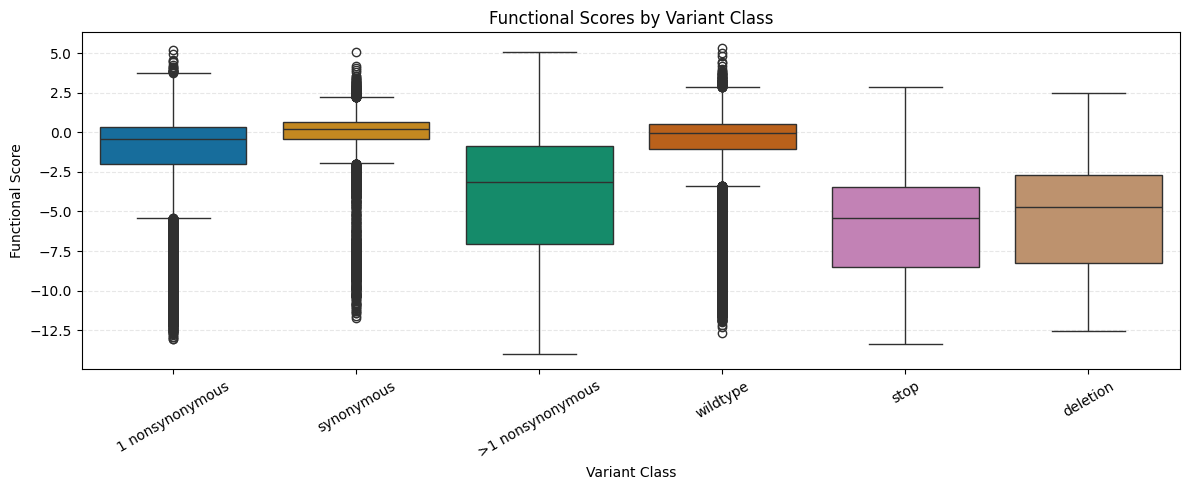

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

sns.boxplot(
    data=func_scores_filtered,
    x="variant_class",
    y="func_score",
    hue="variant_class",      
    palette="colorblind",           
    legend=False
)

plt.xlabel("Variant Class")
plt.ylabel("Functional Score")
plt.title("Functional Scores by Variant Class")

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

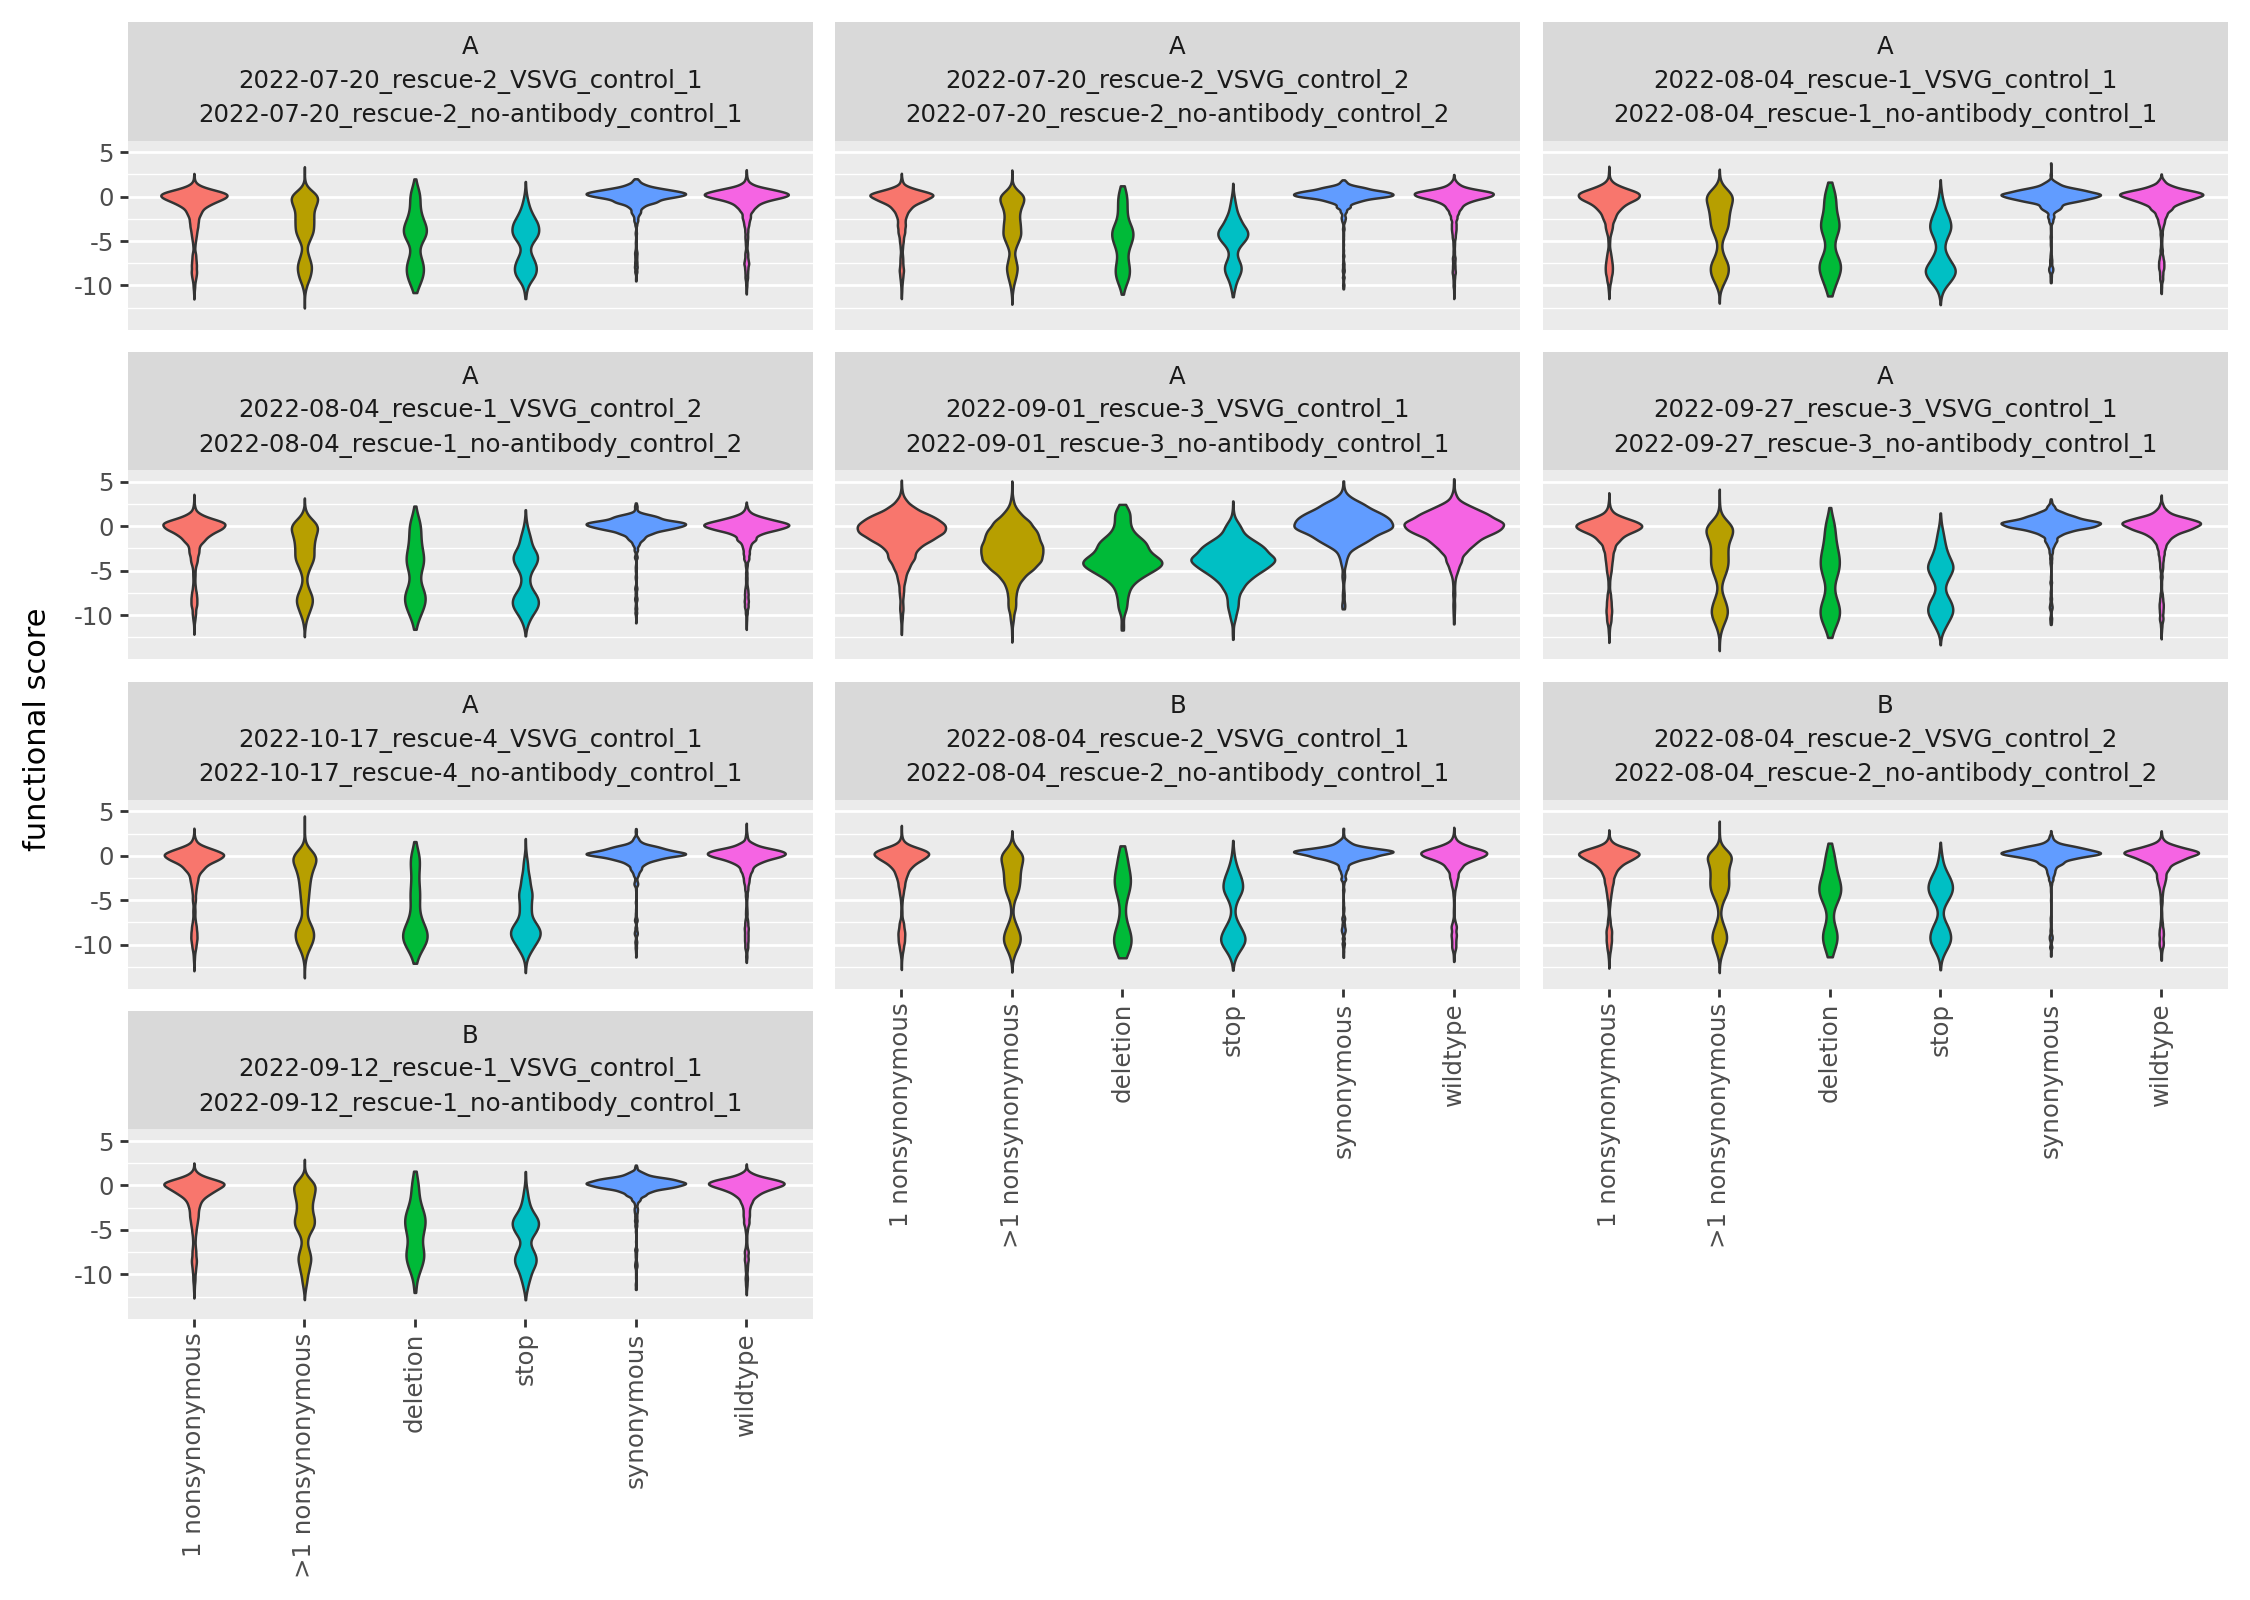

In [27]:
import math
import plotnine as p9


# Fix dtype issues

func_scores_filtered["variant_class"] = (
    func_scores_filtered["variant_class"]
    .astype(str)
)


# Layout

ncols = 3

nrows = math.ceil(
    len(
        func_scores_filtered.groupby(
            [
                "library",
                "pre_sample",
                "post_sample",
            ]
        )
    ) / ncols
)


# Violin plot

p = (
    p9.ggplot(
        func_scores_filtered,
        p9.aes(
            x="variant_class",
            y="func_score",
        ),
    )

    + p9.geom_violin(
        p9.aes(
            fill="variant_class"
        )
    )

    + p9.ylab(
        "functional score"
    )

    + p9.xlab("")

    + p9.facet_wrap(
        "~ library + pre_sample + post_sample",
        ncol=ncols,
    )

    + p9.theme(
        figure_size=(
            3.75 * ncols,
            2 * nrows,
        ),

        axis_text_x=p9.element_text(
            angle=90
        ),

        panel_grid_major_x=p9.element_blank(),
    )

    + p9.scale_fill_discrete(
        guide=None
    )
)


# Draw

p

In [28]:
import os

variant_path = (
    "/home/lechiffre/"
    "HIV_Envelope_BF520_DMS_CD4bs_sera/"
    "results/variant_counts"
)

files = os.listdir(variant_path)

for f in files[:20]:
    print(f)

B_2022-09-27_rescue-3_antibody_IDC561_2.0_1.csv
A_2022-10-17_rescue-4_antibody_3BNC117_1.0_1.csv
A_2022-09-01_rescue-3_VSVG_control_1.csv
A_2022-10-17_rescue-4_no-antibody_control_1.csv
A_2022-08-04_rescue-1_no-antibody_control_1.csv
A_2022-07-20_rescue-2_VSVG_control_2.csv
A_2022-07-20_rescue-2_no-antibody_control_1.csv
A_2022-07-20_rescue-2_VSVG_control_1.csv
B_2022-09-12_rescue-1_no-antibody_control_1.csv
A_2022-08-04_rescue-1_no-antibody_control_2.csv
A_2022-07-20_rescue-2_antibody_1-18_2.0_2.csv
B_2022-09-27_rescue-3_antibody_IDC508_2.0_1.csv
A_2022-10-17_rescue-4_antibody_IDC513_7.5_1.csv
A_2022-09-27_rescue-3_antibody_IDC561_2.0_1.csv
A_2022-10-17_rescue-4_antibody_3BNC117_2.0_1.csv
A_2022-09-01_rescue-3_no-antibody_control_2.csv
B_2022-09-27_rescue-3_antibody_IDC508_3.0_1.csv
B_2022-10-11_rescue-4_antibody_IDC513_10.0_1.csv
B_2022-09-27_rescue-3_antibody_IDF033_1.0_1.csv
A_2022-10-17_rescue-4_antibody_IDC513_10.0_1.csv


Index(['barcode', 'count', 'codon_substitutions', 'aa_substitutions',
       'variant_call_support'],
      dtype='str')
Merged shape:
(44759, 3)

Pearson correlation
-------------------
r = 0.9571956697657343
p = 0.0


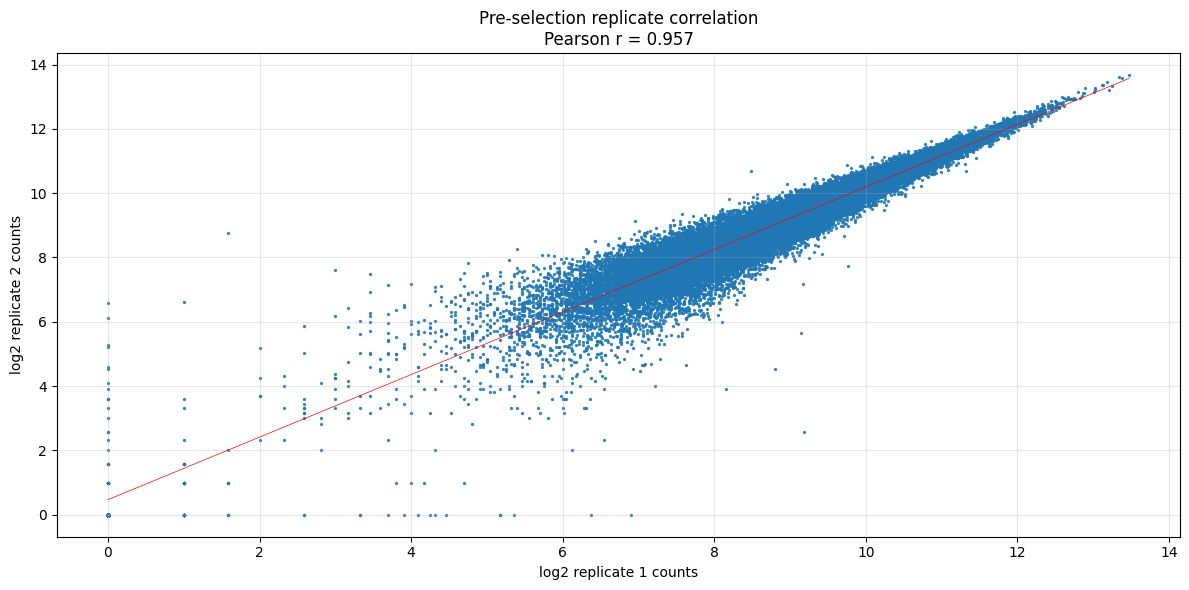

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



# LOAD REPLICATE FILES


rep1 = pd.read_csv(
    "/home/lechiffre/HIV_Envelope_BF520_DMS_CD4bs_sera/results/variant_counts/A_2022-08-04_rescue-1_VSVG_control_1.csv"
)

rep2 = pd.read_csv(
    "/home/lechiffre/HIV_Envelope_BF520_DMS_CD4bs_sera/results/variant_counts/A_2022-08-04_rescue-1_VSVG_control_2.csv"
)



# CHECK COLUMNS


print(rep1.columns)



# KEEP BARCODE + COUNTS


rep1 = rep1[["barcode", "count"]].rename(
    columns={
        "count": "count_rep1"
    }
)

rep2 = rep2[["barcode", "count"]].rename(
    columns={
        "count": "count_rep2"
    }
)



# MERGE REPLICATES


merged = rep1.merge(
    rep2,
    on="barcode",
    how="inner"
)

print("Merged shape:")
print(merged.shape)



# ADD PSEUDOCOUNT


merged["count_rep1"] += 1
merged["count_rep2"] += 1



# LOG TRANSFORM


merged["log_rep1"] = np.log2(
    merged["count_rep1"]
)

merged["log_rep2"] = np.log2(
    merged["count_rep2"]
)



# PEARSON CORRELATION


r, p = pearsonr(
    merged["log_rep1"],
    merged["log_rep2"]
)

print("\nPearson correlation")
print("-------------------")
print("r =", r)
print("p =", p)



# REGRESSION LINE


m, b = np.polyfit(
    merged["log_rep1"],
    merged["log_rep2"],
    1
)

x = np.linspace(
    merged["log_rep1"].min(),
    merged["log_rep1"].max(),
    200
)

y = m * x + b



# PLOT


plt.figure(figsize=(12, 6))

# Scatterplot
plt.scatter(
    merged["log_rep1"],
    merged["log_rep2"],
    alpha=0.8,
    s=2,
)

# Regression line
plt.plot(
    x,
    y,
    linewidth=0.5,
    color="red",
)

plt.xlabel(
    "log2 replicate 1 counts"
)

plt.ylabel(
    "log2 replicate 2 counts"
)

plt.title(
    f"Pre-selection replicate correlation\nPearson r = {r:.3f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Files found: 72
Replicate pairs: 12
Merged A_2022-10-17_rescue-4_no-antibody_control: (44759, 4)
Merged A_2022-08-04_rescue-1_no-antibody_control: (44759, 4)
Merged A_2022-07-20_rescue-2_VSVG_control: (44759, 4)
Merged A_2022-07-20_rescue-2_no-antibody_control: (44759, 4)
Merged A_2022-07-20_rescue-2_antibody_1-18_2.0: (44759, 4)
Merged A_2022-09-01_rescue-3_no-antibody_control: (44759, 4)
Merged A_2022-08-04_rescue-1_VSVG_control: (44759, 4)
Merged B_2022-09-27_rescue-3_no-antibody_control: (42519, 4)
Merged B_2022-10-11_rescue-4_no-antibody_control: (42519, 4)
Merged A_2022-07-20_rescue-2_antibody_PGT151_2.0: (44759, 4)
Merged B_2022-08-04_rescue-2_VSVG_control: (42519, 4)
Merged B_2022-08-04_rescue-2_no-antibody_control: (42519, 4)

Combined replicate shape:
(528148, 4)

Global Pearson correlation
r = 0.847508964096118
p = 0.0


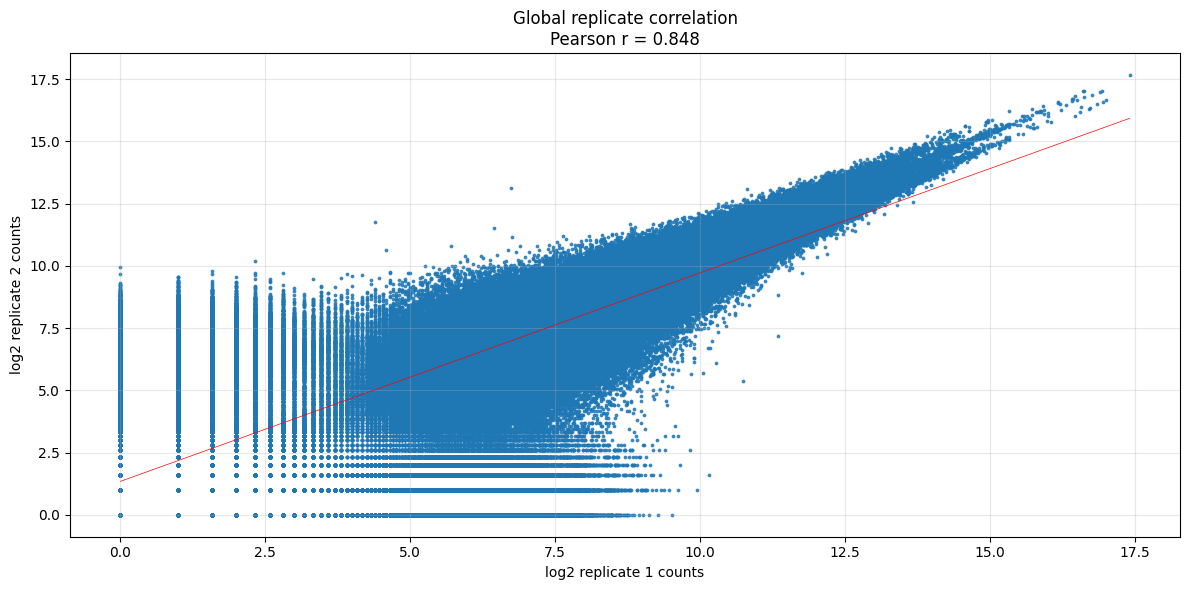

In [36]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



# VARIANT COUNT FOLDER

variant_folder = ("/home/lechiffre/HIV_Envelope_BF520_DMS_CD4bs_sera/results/variant_counts"
)

# FIND CSV FILES
files = glob.glob(os.path.join(variant_folder, "*.csv"))
print("Files found:", len(files))

# GROUP REPLICATES

replicate_pairs = {}

for f in files:

    filename = os.path.basename(f)

    # remove replicate suffix
    base = filename.replace("_1.csv", "").replace("_2.csv", "")

    if base not in replicate_pairs:
        replicate_pairs[base] = []

    replicate_pairs[base].append(f)


# KEEP ONLY TRUE REPLICATE PAIRS

valid_pairs = {
    k: v
    for k, v in replicate_pairs.items()
    if len(v) == 2
}

print("Replicate pairs:", len(valid_pairs))


# MERGE ALL REPLICATES

merged_list = []

for pair_name, pair_files in valid_pairs.items():

    pair_files = sorted(pair_files)

    rep1 = pd.read_csv(pair_files[0])
    rep2 = pd.read_csv(pair_files[1])

    # keep barcode + count
    rep1 = rep1[["barcode", "count"]].rename(
        columns={"count": "count_rep1"}
    )

    rep2 = rep2[["barcode", "count"]].rename(
        columns={"count": "count_rep2"}
    )

    # merge on barcode
    merged = rep1.merge(
        rep2,
        on="barcode",
        how="inner"
    )

    merged["sample_pair"] = pair_name

    merged_list.append(merged)

    print(f"Merged {pair_name}:",merged.shape
    )

# COMBINE EVERYTHING
all_reps = pd.concat(
    merged_list,
    ignore_index=True
)

print("\nCombined replicate shape:")
print(all_reps.shape)


# ADD PSEUDOCOUNT
all_reps["count_rep1"] += 1
all_reps["count_rep2"] += 1


# LOG TRANSFORM
all_reps["log_rep1"] = np.log2(all_reps["count_rep1"]
)

all_reps["log_rep2"] = np.log2(all_reps["count_rep2"]
)


# GLOBAL CORRELATION

r, p = pearsonr(
    all_reps["log_rep1"],
    all_reps["log_rep2"]
)

print("\nGlobal Pearson correlation")
print("r =", r)
print("p =", p)


# REGRESSION LINE

m, b = np.polyfit(
    all_reps["log_rep1"],
    all_reps["log_rep2"],
    1
)

x = np.linspace(
    all_reps["log_rep1"].min(),
    all_reps["log_rep1"].max(),
    300
)

y = m * x + b

# PLOT

plt.figure(figsize=(12, 6))

# scatter cloud
plt.scatter(
    all_reps["log_rep1"],
    all_reps["log_rep2"],
    alpha=0.8,
    s=3,
)

# regression line
plt.plot(x,y,linewidth=0.5,color="red",
)

plt.xlabel("log2 replicate 1 counts"
)

plt.ylabel("log2 replicate 2 counts"
)

plt.title(f"Global replicate correlation\nPearson r = {r:.3f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

(44751, 3)
Pearson r = 0.7537334647694773


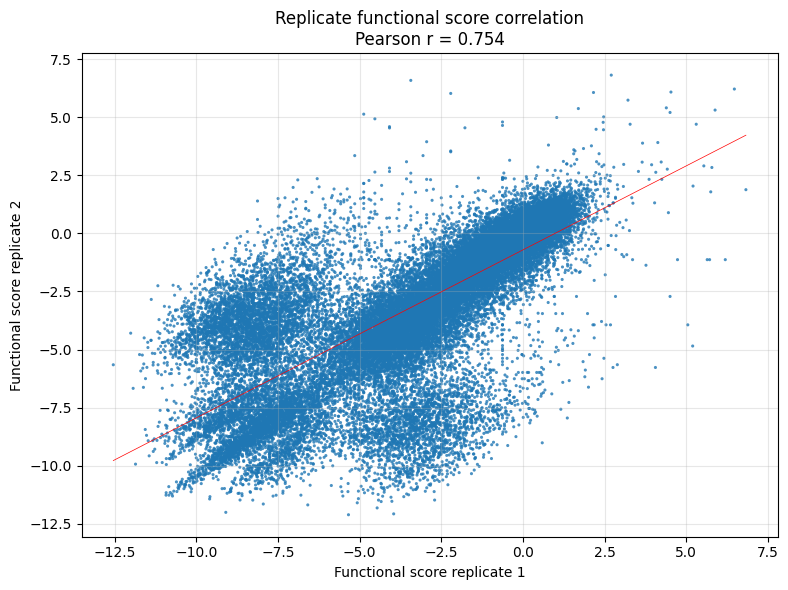

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



# LOAD REPLICATE FUNCTIONAL SCORE FILES

rep1 = pd.read_csv(
    "../results/func_scores/merged_output_clean/mapped_output_clean/pipeline_output/A_2022-07-20_rescue-2_VSVG_control_1_vs_2022-07-20_rescue-2_no-antibody_control_1_merged_mapped_pipeline.csv"
)

rep2 = pd.read_csv(
    "../results/func_scores/merged_output_clean/mapped_output_clean/pipeline_output/A_2022-07-20_rescue-2_VSVG_control_2_vs_2022-07-20_rescue-2_no-antibody_control_2_merged_mapped_pipeline.csv"
)



# KEEP RELEVANT COLUMNS

rep1 = rep1[
    [
        "barcode",
        "func_score"
    ]
].rename(
    columns={
        "func_score": "func_score_rep1"
    }
)

rep2 = rep2[
    [
        "barcode",
        "func_score"
    ]
].rename(
    columns={
        "func_score": "func_score_rep2"
    }
)



# MERGE BY BARCODE

merged = rep1.merge(
    rep2,
    on="barcode",
    how="inner"
)

merged = merged.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()


print(merged.shape)



# PEARSON CORRELATION

r, p = pearsonr(
    merged["func_score_rep1"],
    merged["func_score_rep2"]
)

print("Pearson r =", r)


# REGRESSION LINE

m, b = np.polyfit(
    merged["func_score_rep1"],
    merged["func_score_rep2"],
    1
)

x = np.linspace(
    merged["func_score_rep1"].min(),
    merged["func_score_rep1"].max(),
    200
)

y = m * x + b



# PLOT

plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(
    merged["func_score_rep1"],
    merged["func_score_rep2"],
    
    alpha=0.8,
    s=5,
    edgecolor="none",
)

# Regression line
plt.plot(
    x,
    y,
    linestyle="-",
    linewidth=0.5,
    color="red",
)


# Labels
plt.xlabel(
    "Functional score replicate 1"
)

plt.ylabel(
    "Functional score replicate 2"
)

plt.title(
    f"Replicate functional score correlation\nPearson r = {r:.3f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

(44751, 2)
Pearson r = -0.5907399207125537
p-value = 0.0


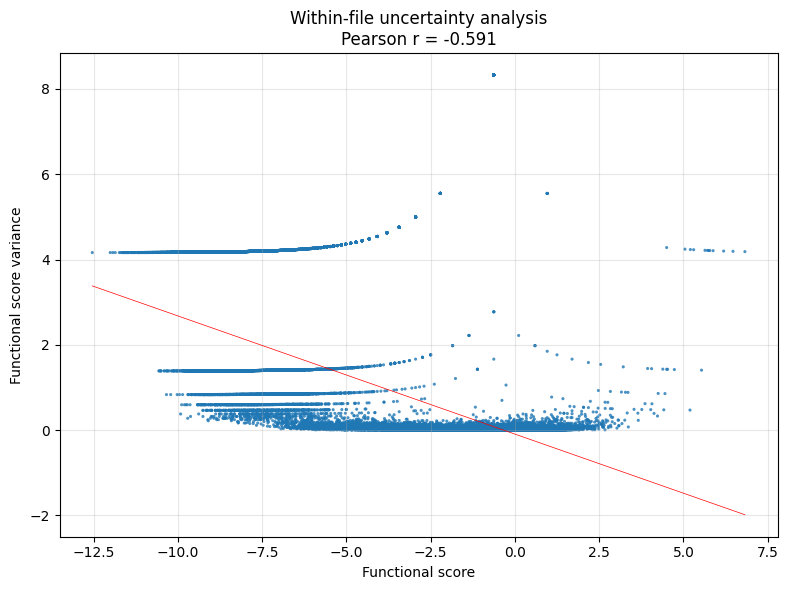

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr



# LOAD ONE FUNCTIONAL SCORE FILE


df = pd.read_csv(
    "../results/func_scores/merged_output_clean/mapped_output_clean/pipeline_output/A_2022-07-20_rescue-2_VSVG_control_1_vs_2022-07-20_rescue-2_no-antibody_control_1_merged_mapped_pipeline.csv"
)


# KEEP RELEVANT COLUMNS


df = df[
    [
        "func_score",
        "func_score_var"
    ]
].copy()

df = df.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

print(df.shape)


# CORRELATION

r, p = pearsonr(
    df["func_score"],
    df["func_score_var"]
)

print("Pearson r =", r)
print("p-value =", p)


# REGRESSION LINE

m, b = np.polyfit(
    df["func_score"],
    df["func_score_var"],
    1
)

x = np.linspace(
    df["func_score"].min(),
    df["func_score"].max(),
    200
)

y = m * x + b


# PLOT

plt.figure(figsize=(8,6))

plt.scatter(
    df["func_score"],
    df["func_score_var"],
    s=5,
    alpha=0.8,
    edgecolors="none"
)

plt.plot(
    x,
    y,
    color="red",
    linewidth=0.5
)

plt.xlabel("Functional score")
plt.ylabel("Functional score variance")

plt.title(
    f"Within-file uncertainty analysis\nPearson r = {r:.3f}"
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()